In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [ ]:
# Configuration and paths
mac = 20

# ============================================================
# Variant class selection — change this to switch variant class
# Available: missense, missense_structured, missense_non_structured,
#   missense_disordered, missense_lip, intron,
#   enhancer_encode, promoter_encode, tf_encode, core_promoter
# ============================================================
variant_class = 'all_variants'
exclude_clinvar = False  # Independent toggle: exclude ClinVar-annotated variants
only_clinvar = False  # Independent toggle: include only ClinVar-annotated variants

# Initialize new annotation variable as None
new_anno_local = None

# Sliding window and bootstrap parameters
window_size = 1_000  # Number of variants in the sliding window
step_size = 1_0      # Step between sampled points (controls plot smoothness)
n_boot = 1_000         # Number of bootstrap resamples across regions
max_num_variants = 100_000  # Maximum number of top-ranked variants per annotation (None = no limit)

# Define the specific discrete cutoffs for the heatmap
target_k = np.array([1_000, 10_000], dtype=np.int64)
# target_k = np.array([1_000, 10_000, 100_000], dtype=np.int64)

# Load variant class configuration
variant_class_path = "/home/dnanexus/ukbgym/config_variant_classes.yaml"
with open(variant_class_path) as f:
    variant_class_config = yaml.safe_load(f)

vc = variant_class_config[variant_class]
vc_filters = vc['variant_filtering']
selected_categories = vc['tool_categories']
x_label = f"Top N {vc['x_label']} variants"

print(f"Variant class: {variant_class}")
print(f"  Filters: {vc_filters}")
print(f"  Categories: {selected_categories}")
print(f"  X-label: {x_label}")
print(f"  Exclude ClinVar: {exclude_clinvar}")

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds.yaml"

with open(config_path) as f:
    config = yaml.safe_load(f)

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

Variant class: all_variants
  Filters: None
  Categories: ['conservation']
  X-label: Top N All variants
  Exclude ClinVar: False


category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""missense""","""clinpred_score""","""#FFDC80""","""ClinPred""",1
"""missense""","""bayes_del""","""#FFBF00""","""BayesDel""",1
"""missense""","""polyphen""","""#FF90AA""","""PolyPhen2""",1
"""missense""","""revel_score""","""#FF7000""","""REVEL""",1
"""missense""","""am_pathogenicity""","""#E63946""","""AlphaMissense""",1
…,…,…,…,…
"""regulatory""","""fz_all_mean""","""#1f77b4""","""Flashzoi mean across RNA (all)""",1
"""regulatory""","""fz_blood_min""","""crimson""","""Flashzoi min across RNA (blood…",-1
"""regulatory""","""fz_all_min""","""#FFA500""","""Flashzoi min across RNA (all)""",-1


In [3]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

# CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
CORR_FILE = "regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per_correlations.parquet"
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per_correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000084674""","""ldl_direct_int""",2.2543e-301,-0.12678,0.12678,-1.0
"""ENSG00000167701""","""alanine_aminotransferase_int""",1.2234e-144,-0.106424,0.106424,-1.0
"""ENSG00000105610""","""mean_corpuscular_haemoglobin_i…",9.8993e-24,-0.100921,0.100921,-1.0
"""ENSG00000141505""","""alkaline_phosphatase_int""",8.4146e-35,0.089171,0.089171,1.0
"""ENSG00000101162""","""platelet_distribution_width_in…",1.5335e-83,0.08869,0.08869,1.0
…,…,…,…,…,…
"""ENSG00000115977""","""sitting_height_int""",0.021257,-0.001496,0.001496,-1.0
"""ENSG00000119574""","""standing_height_int""",0.025535,-0.001317,0.001317,-1.0
"""ENSG00000115325""","""platelet_distribution_width_in…",0.01277,-0.001204,0.001204,-1.0


In [ ]:
new_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/flashzoi_scores"
new_anno_filename = "ukbbgym_TSS_promoter_enhancer_TF_variants_all_260218_0_ukbbgym.parquet"
!dx download {new_anno_path}/{new_anno_filename} -o /home/dnanexus/data_dir/

new_anno_local = f'/home/dnanexus/data_dir/{new_anno_filename}'

new_anno_df = pl.scan_parquet(new_anno_local)
# rna_cols = [c for c in new_anno_df.collect_schema().names() if c.startswith('RNA:')]
# 89 GTEx tissue tracks:
gtex_cols = ['RNA:adipose_tissue_7522', 'RNA:adipose_tissue_7523', 'RNA:adipose_tissue_7524', 'RNA:adrenal_gland_7525', 'RNA:adrenal_gland_7526', 'RNA:adrenal_gland_7527', 'RNA:bladder_7528', 'RNA:bladder_7529', 'RNA:bladder_7530', 'RNA:blood_7531', 'RNA:blood_7532', 'RNA:blood_7533', 'RNA:blood_vessel_7534', 'RNA:blood_vessel_7535', 'RNA:blood_vessel_7536', 'RNA:bone_marrow_7537', 'RNA:bone_marrow_7538', 'RNA:brain_7539', 'RNA:brain_7540', 'RNA:brain_7541', 'RNA:breast_7542', 'RNA:breast_7543', 'RNA:breast_7544', 'RNA:cervix_uteri_7545', 'RNA:cervix_uteri_7546', 'RNA:cervix_uteri_7547', 'RNA:colon_7548', 'RNA:colon_7549', 'RNA:colon_7550', 'RNA:esophagus_7551', 'RNA:esophagus_7552', 'RNA:esophagus_7553', 'RNA:fallopian_tube_7554', 'RNA:fallopian_tube_7555', 'RNA:fallopian_tube_7556', 'RNA:heart_7557', 'RNA:heart_7558', 'RNA:heart_7559', 'RNA:kidney_7560', 'RNA:kidney_7561', 'RNA:kidney_7562', 'RNA:liver_7563', 'RNA:liver_7564', 'RNA:liver_7565', 'RNA:lung_7566', 'RNA:lung_7567', 'RNA:lung_7568', 'RNA:muscle_7569', 'RNA:muscle_7570', 'RNA:muscle_7571', 'RNA:nerve_7572', 'RNA:nerve_7573', 'RNA:ovary_7574', 'RNA:ovary_7575', 'RNA:ovary_7576', 'RNA:pancreas_7577', 'RNA:pancreas_7578', 'RNA:pancreas_7579', 'RNA:pituitary_7580', 'RNA:pituitary_7581', 'RNA:pituitary_7582', 'RNA:prostate_7583', 'RNA:prostate_7584', 'RNA:prostate_7585', 'RNA:salivary_gland_7586', 'RNA:salivary_gland_7587', 'RNA:salivary_gland_7588', 'RNA:skin_7589', 'RNA:skin_7590', 'RNA:skin_7591', 'RNA:small_intestine_7592', 'RNA:small_intestine_7593', 'RNA:small_intestine_7594', 'RNA:spleen_7595', 'RNA:spleen_7596', 'RNA:spleen_7597', 'RNA:stomach_7598', 'RNA:stomach_7599', 'RNA:stomach_7600', 'RNA:testis_7601', 'RNA:testis_7602', 'RNA:thyroid_7603', 'RNA:thyroid_7604', 'RNA:thyroid_7605', 'RNA:uterus_7606', 'RNA:uterus_7607', 'RNA:vagina_7608', 'RNA:vagina_7609', 'RNA:vagina_7610']

new_anno_df = (
    new_anno_df
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .with_columns(
        fz_all_min = pl.min_horizontal(cs.starts_with('RNA:')),
        fz_gtex_min = pl.min_horizontal(gtex_cols),
    )
    .select(['id', 'region', 'fz_all_min', 'fz_gtex_min'])
    .collect()
)

new_anno_df

Error: path "/home/dnanexus/data_dir/ukbbgym_TSS_promoter_enhancer_TF_variants
_all_260218_0_ukbbgym.parquet" already exists but -f/--overwrite was not set


/tmp/ipykernel_40924/2215979549.py:18: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,fz_all_min,fz_all_max,fz_all_mean
str,str,f32,f32,f32
"""chr22:24594263:T:G""","""ENSG00000100031""",-0.008994,0.001747,0.003926
"""chr14:59368918:C:T""","""ENSG00000100592""",-0.033651,0.004826,0.004763
"""chr17:50205580:T:C""","""ENSG00000108821""",-0.038777,0.027446,0.003392
"""chr5:76418836:T:C""","""ENSG00000145703""",-0.000617,0.001371,0.000237
"""chr14:59213667:G:T""","""ENSG00000100592""",-0.002696,0.003707,0.000671
…,…,…,…,…
"""chr4:88012364:C:G""","""ENSG00000118762""",-0.002406,0.004344,0.000717
"""chr7:153910910:T:C""","""ENSG00000130226""",-0.004095,0.00267,0.00088
"""chr19:17111312:C:T""","""ENSG00000099331""",-0.002071,0.00233,0.000114


In [5]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"
ANNO_FILE = "annotations_with_all.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# If True, fillna variants are kept but ranked at the bottom of each annotation
# keep_fillna = True  

# Join new annotation if specified above
if new_anno_local is not None:
    anno = (
        anno
        .join(
            new_anno_df.lazy(),
            on=['id', 'region'],
            how='left'
        )
    )

# Build dynamic filters from variant_class.yaml
if vc_filters is not None:
    _dynamic_filters = [eval(f) for f in vc_filters]
else:
    _dynamic_filters = []

if exclude_clinvar:
    _dynamic_filters.append(pl.col('clinical_significance').is_null())
elif only_clinvar:
    _dynamic_filters.append(pl.col('clinical_significance').is_not_null())

anno = (
    anno
    .with_columns(
        encode_any_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca-tf']),
        encode_enhancer = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pels', 'encode_dels']),
        encode_promoter = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_ca-h3k4me3']),
    )
    .filter(
        # Always-applied filters
        (pl.col('region').is_in(gene_trait_df['region'].unique())),
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1),

        # Dynamic filters from variant_class.yaml + exclude_clinvar
        *_dynamic_filters,
    )
)

# selected_categories is already set from YAML in the config cell

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

Error: path "/home/dnanexus/data_dir/annotations_with_all.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_40924/2540309885.py:58: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_40924/2540309885.py:67: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


zooverphylop,mamphylop,verphylop,zoopriphylop,id,priphylop,region
f32,f32,f32,f32,str,f32,str
-0.386,0.421,0.437,0.292,"""chr2:158622652:T:A""",0.321,"""ENSG00000144283"""
-2.539,-0.895,-0.905,0.0,"""chr17:64576402:G:A""",-1.423,"""ENSG00000108854"""
0.449,0.333,0.335,0.999,"""chr12:48044213:T:C""",0.467,"""ENSG00000079387"""
1.079,-0.073,-0.061,0.319,"""chr3:141549250:C:G""",0.417,"""ENSG00000155903"""
0.288,0.184,0.186,0.076,"""chr9:69117147:C:T""",0.182,"""ENSG00000119139"""
…,…,…,…,…,…,…
0.319,0.246,0.238,0.013,"""chr2:233736562:G:T""",0.247,"""ENSG00000242366"""
0.682,0.055,0.033,0.168,"""chr12:101109210:G:A""",0.595,"""ENSG00000151572"""
-2.865,-1.271,-1.302,0.0,"""chr5:172048980:C:T""",0.289,"""ENSG00000072786"""


In [6]:
anno_fillna = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
fillna_cols = set([c+'_is_na' for c in selected_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .select(['id', 'region'] + list(fillna_cols))
    .join(
        anno.select(['id', 'region']).lazy(), 
        on=['id', 'region'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == 1
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
)

anno_fillna_melted.head().collect()

/tmp/ipykernel_40924/2928459309.py:27: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_is_na
str,str,str,i8
"""chr4:81187384:A:C""","""ENSG00000138669""","""priphylop""",1
"""chr4:81183596:T:C""","""ENSG00000138669""","""priphylop""",1
"""chr1:162739238:C:A""","""ENSG00000162733""","""priphylop""",1
"""chr12:21209271:A:G""","""ENSG00000134538""","""priphylop""",1
"""chr14:92044591:G:C""","""ENSG00000100815""","""priphylop""",1


In [7]:
melted_anno = (
    anno.lazy()

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).lazy(),
        on="annotation",
        how="left"
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()

    # Remove null annotation scores
    .drop_nulls('annotation_score')

    # Remove variants for each annotation which are not scored
    .join(
        anno_fillna_melted,
        on=['id', 'region', 'annotation'],
        how='anti'
    )

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="max", descending=True).over(["annotation"]).cast(pl.Float32)
    )
    .drop(['annotation_score_dircor'])

    .collect(engine='streaming')
)

melted_anno

/tmp/ipykernel_40924/1598827054.py:45: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank_desc
str,str,str,f32,str,i8,f32
"""chr7:80396295:G:A""","""ENSG00000135218""","""zooverphylop""",-0.003,"""conservation""",1,1.0234323e7
"""chr4:84938210:A:T""","""ENSG00000163625""","""zooverphylop""",-1.869,"""conservation""",1,1.7538444e7
"""chr15:64568973:C:A""","""ENSG00000180357""","""zooverphylop""",-1.035,"""conservation""",1,1.6137599e7
"""chr12:96876884:C:T""","""ENSG00000188596""","""zooverphylop""",1.467,"""conservation""",1,1.562174e6
"""chr2:1746105:A:T""","""ENSG00000130508""","""zooverphylop""",0.263,"""conservation""",1,7.260951e6
…,…,…,…,…,…,…
"""chr3:78686372:C:T""","""ENSG00000169855""","""zooverphylop""",-1.178,"""conservation""",1,1.6481399e7
"""chr3:124372963:T:C""","""ENSG00000160145""","""zooverphylop""",-1.635,"""conservation""",1,1.7226776e7
"""chr2:143508744:G:A""","""ENSG00000075884""","""zooverphylop""",-0.096,"""conservation""",1,1.1110278e7


In [8]:
melted_anno['annotation'].value_counts(sort=True)

annotation,count
str,u64
"""zooverphylop""",18706256
"""zoopriphylop""",18706256
"""mamphylop""",18652893
"""verphylop""",18652893
"""priphylop""",18652893


In [9]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
pheno_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Filter to variants in annotation set and low MAC
anno_keys = anno.select(pl.col('id').unique()).lazy()

pheno_appv = (
    pheno_appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)

Error: path "/home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated
_miss20per_appv_small.parquet" already exists but -f/--overwrite was not set


## Average z-score by annotation rank (sliding window)

In [10]:
# --- Re-ranking bootstrap: join variant z-scores with annotation ranks ---
id_region = anno.select(['id', 'region']).unique().lazy()

# Get variant-level z-scores joined with gene_trait_df
# Direction-correct mean_pheno_value: if loftee_corr_dir == -1, flip the z-score
# so that "deleterious" variants always have positive z-scores
variant_zscores = (
    pheno_appv
    .join(id_region, on='id', how='inner')
    .join(gene_trait_df.lazy(), on=['region', 'phenotype'], how='inner')
    .with_columns(
        mean_pheno_value = pl.col('mean_pheno_value') * pl.col('loftee_corr_dir').cast(pl.Float32)
    )
    .select(['id', 'region', 'mean_pheno_value'])
    .collect(engine='streaming')
)

print(f"Variant z-scores: {variant_zscores.shape[0]} variant-gene pairs")

# Join z-scores with annotation ranks, sort by rank (most deleterious first)
ranked_zscores = (
    variant_zscores.lazy()
    .join(
        melted_anno.lazy().select(['id', 'region', 'annotation', 'annotation_score_dircor_rank_desc']),
        on=['id', 'region'],
        how='inner'
    )
    .sort(['annotation', 'annotation_score_dircor_rank_desc'])
    .with_columns(
        row_pos = pl.col('annotation').cum_count().over('annotation'),
    )
    .pipe(lambda df: df.filter(pl.col('row_pos') <= max_num_variants) if max_num_variants is not None else df)
    .collect(engine='streaming')
)

# Map regions to integer indices for fast bootstrap resampling
all_regions = sorted(gene_trait_df['region'].unique().to_list())
n_regions = len(all_regions)
region_idx_map = pl.DataFrame({'region': all_regions, '_region_idx': np.arange(n_regions, dtype=np.int32)})
ranked_zscores = ranked_zscores.join(region_idx_map, on='region', how='left')

annotations_list = sorted(ranked_zscores['annotation'].unique().to_list())


# --- Helper functions ---

def sliding_window_means_unweighted(zscores, bin_ends, window_size):
    """Standard prefix-sum sliding window mean (for point estimates)."""
    csum = np.empty(len(zscores) + 1, dtype=np.float64)
    csum[0] = 0.0
    np.cumsum(zscores, out=csum[1:])
    return (csum[bin_ends] - csum[bin_ends - window_size]) / window_size


def expanded_csum_at(positions, cw, cwz, z, N):
    """Compute the prefix sum of the virtual expanded array at given positions.
    
    The "expanded array" is the conceptual array where variant i is repeated
    w[i] times (its gene's bootstrap weight). Instead of materializing this
    array (which changes every iteration), we compute its prefix sum
    analytically using binary search into the cumulative weight array.
    
    For expanded position e, we find the original variant k whose copies
    span that position, then:
        expanded_csum[e] = cwz[k-1] + z[k-1] * (e - cw[k-1])
    
    This is the full weighted prefix sum up to variant k-2, plus a partial
    contribution from variant k-1 for the copies that fall within [1, e].
    
    Parameters
    ----------
    positions : int array — positions in the expanded (virtual) array
    cw  : float array (N+1,) — cumulative variant weights, cw[0]=0
    cwz : float array (N+1,) — cumulative (z * weight), cwz[0]=0
    z   : float array (N,)   — z-scores in original sort order
    N   : int — number of original variants
    """
    k = np.searchsorted(cw, positions, side='left')
    k_safe = np.clip(k, 1, N)
    result = cwz[k_safe - 1] + z[k_safe - 1] * (positions - cw[k_safe - 1])
    result = np.where(positions <= 0, 0.0, result)
    return result


def sliding_window_reranked(z, cw, cwz, N, total_expanded, bin_ends, window_size):
    """Sliding window mean on the virtual expanded (re-ranked) array.
    
    Returns an array of means at each bin_end position.
    Positions beyond the expanded array length are NaN.
    """
    valid_mask = bin_ends <= total_expanded
    valid_bins = bin_ends[valid_mask]
    means = np.full(len(bin_ends), np.nan, dtype=np.float64)
    if len(valid_bins) == 0:
        return means

    right = expanded_csum_at(valid_bins, cw, cwz, z, N)
    left = expanded_csum_at(valid_bins - window_size, cw, cwz, z, N)
    means[valid_mask] = (right - left) / window_size
    return means


# --- Prepare per-annotation sorted arrays and bin endpoints ---
anno_arrays = {}
for annotation in tqdm(annotations_list, desc='Preparing arrays'):
    adf = ranked_zscores.filter(pl.col('annotation') == annotation)
    z = adf['mean_pheno_value'].to_numpy().astype(np.float64)
    r_idx = adf['_region_idx'].to_numpy()
    N = len(z)

    # bin_ends defined on the full (unbootstrapped) data
    bin_ends = np.arange(window_size, N + 1, step_size, dtype=np.int64)

    anno_arrays[annotation] = {
        'zscores': z,
        'region_idx': r_idx,
        'bin_ends': bin_ends,
        'N': N,
    }

# Filter target_k to exclude thresholds exceeding the minimum variant count
min_variants = min(d['N'] for d in anno_arrays.values())
target_k = target_k[target_k <= min_variants]
print(f"Heatmap thresholds after filtering: {target_k} (min variants across annotations: {min_variants})")

# --- Point estimates (unweighted, on full data) ---
point_means = {}
for annotation in annotations_list:
    d = anno_arrays[annotation]
    point_means[annotation] = sliding_window_means_unweighted(
        d['zscores'], d['bin_ends'], window_size
    )

# --- Re-ranking bootstrap CIs across regions ---
rng = np.random.default_rng(42)

# pre-allocation for the line plot
boot_means = {ann: np.full((n_boot, len(anno_arrays[ann]['bin_ends'])), np.nan)
              for ann in annotations_list}

# pre-allocation for the heatmap
boot_discrete = {ann: np.full((n_boot, len(target_k)), np.nan) 
                 for ann in annotations_list}

# Pre-allocate buffers to avoid repeated memory allocation in the hot loop
max_N = max(d['N'] for d in anno_arrays.values())
cw_buf = np.empty(max_N + 1, dtype=np.float64)
cwz_buf = np.empty(max_N + 1, dtype=np.float64)

for b in tqdm(range(n_boot), desc='Re-ranking bootstrap'):
    idx = rng.choice(n_regions, size=n_regions, replace=True)
    region_weights = np.bincount(idx, minlength=n_regions).astype(np.float64)

    for annotation in annotations_list:
        d = anno_arrays[annotation]
        N = d['N']
        z = d['zscores']
        vw = region_weights[d['region_idx']]

        # Build cumulative weight and cumulative weighted-z using pre-allocated buffers
        cw = cw_buf[:N + 1]
        cw[0] = 0.0
        np.cumsum(vw, out=cw[1:])

        cwz = cwz_buf[:N + 1]
        cwz[0] = 0.0
        np.cumsum(z * vw, out=cwz[1:])

        total_expanded = int(cw[N])

        # 1. Calculate Sliding Window (for the Line Plot)
        boot_means[annotation][b] = sliding_window_reranked(
            z, cw, cwz, N, total_expanded, d['bin_ends'], window_size
        )

        # 2. Calculate Discrete Top-K (for the Heatmap)
        # The mean of the top K is the cumulative sum at K, divided by K
        csums = expanded_csum_at(target_k, cw, cwz, z, N)
        boot_discrete[annotation][b] = csums / target_k

# --- Build output DataFrame with percentile-based CIs ---
# ci_factor = 1.96  # For 95% CI
ci_factor = 1  # For 95% CI

all_results = []
for annotation in tqdm(annotations_list):
    d = anno_arrays[annotation]
    pm = point_means[annotation].astype(np.float32)
    bm = boot_means[annotation]
    boot_mean = np.nanmean(bm, axis=0)
    boot_se = np.nanstd(bm, axis=0).astype(np.float32)

    all_results.append(pl.DataFrame({
        'annotation': annotation,
        'bin_end': d['bin_ends'].astype(np.float64),
        # 'mean_zscore': pm,
        # 'ci_lower': np.nanpercentile(bm, 2.5, axis=0).astype(np.float32),
        # 'ci_upper': np.nanpercentile(bm, 97.5, axis=0).astype(np.float32),
        'mean_zscore': boot_mean,
        'se_zscore': boot_se,
        'ci_lower': (boot_mean - ci_factor * boot_se).astype(np.float32),
        'ci_upper': (boot_mean + ci_factor * boot_se).astype(np.float32),
    }))

zscore_binned = pl.concat(all_results).sort(['annotation', 'bin_end'])

print(f"Sliding window results: {zscore_binned.shape[0]} points across {zscore_binned['annotation'].n_unique()} annotations")
zscore_binned

Variant z-scores: 16541188 variant-gene pairs


Preparing arrays: 100%|██████████| 5/5 [00:00<00:00, 245.88it/s]


Heatmap thresholds after filtering: [ 1000 10000] (min variants across annotations: 100000)


100%|██████████| 5/5 [00:00<00:00,  6.15it/s]

Sliding window results: 49505 points across 5 annotations


annotation,bin_end,mean_zscore,se_zscore,ci_lower,ci_upper
str,f64,f64,f32,f32,f32
"""mamphylop""",1000.0,0.103859,0.022739,0.081119,0.126598
"""mamphylop""",1010.0,0.104391,0.022838,0.081553,0.127229
"""mamphylop""",1020.0,0.105662,0.022906,0.082756,0.128567
"""mamphylop""",1030.0,0.105666,0.023003,0.082663,0.128669
"""mamphylop""",1040.0,0.104767,0.023018,0.081749,0.127785
…,…,…,…,…,…
"""zooverphylop""",99960.0,0.096821,0.037961,0.058861,0.134782
"""zooverphylop""",99970.0,0.09683,0.037492,0.059338,0.134322
"""zooverphylop""",99980.0,0.096993,0.037435,0.059558,0.134428


## Plotting

In [11]:
plt_df = (
    zscore_binned
    .drop_nans()
    .with_columns(
        log_bin_end = pl.col('bin_end').log10(),
        log_bin_end_inv = (1 / pl.col('bin_end')).log10(),
    )
    .join(
        anno_config_df.filter(pl.col('category').is_in(selected_categories)).select(['annotation', 'color', 'label', 'category']).unique(),
        on='annotation',
        how='left'
    )
    .filter(pl.col('category').is_in(selected_categories))
    .sort('bin_end')
)

plt_df

annotation,bin_end,mean_zscore,se_zscore,ci_lower,ci_upper,log_bin_end,log_bin_end_inv,color,label,category
str,f64,f64,f32,f32,f32,f64,f64,str,str,str
"""mamphylop""",1000.0,0.103859,0.022739,0.081119,0.126598,3.0,-3.0,"""#006B6B""","""Mammalian PhyloP""","""conservation"""
"""priphylop""",1000.0,-0.012043,0.02626,-0.038303,0.014217,3.0,-3.0,"""#3F007D""","""Primate PhyloP""","""conservation"""
"""verphylop""",1000.0,0.142269,0.03217,0.110099,0.17444,3.0,-3.0,"""#08306B""","""Vertebrate PhyloP""","""conservation"""
"""zoopriphylop""",1000.0,0.029409,0.031599,-0.00219,0.061008,3.0,-3.0,"""#807DBA""","""Zoonomia Primate PhyloP""","""conservation"""
"""zooverphylop""",1000.0,0.029717,0.025975,0.003743,0.055692,3.0,-3.0,"""#2879B9""","""Zoonomia Vertebrate PhyloP""","""conservation"""
…,…,…,…,…,…,…,…,…,…,…
"""mamphylop""",100000.0,0.048222,0.04913,-0.000908,0.097351,5.0,-5.0,"""#006B6B""","""Mammalian PhyloP""","""conservation"""
"""priphylop""",100000.0,0.007137,0.035294,-0.028157,0.042432,5.0,-5.0,"""#3F007D""","""Primate PhyloP""","""conservation"""
"""verphylop""",100000.0,0.097682,0.054907,0.042774,0.152589,5.0,-5.0,"""#08306B""","""Vertebrate PhyloP""","""conservation"""


In [12]:
# LOFTEE point
loftee_vars = (
    pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .filter(pl.col('loftee_hc')==1)
    .collect(engine='streaming')
)

id_region = loftee_vars.select(['id', 'region']).unique().lazy()

# Get variant-level z-scores joined with olink whitelist
loftee_zscores = (
    pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")
    .join(id_region, on='id', how='inner')
    .join(gene_trait_df.lazy(), on=['region', 'phenotype'], how='inner')
    .with_columns(
        mean_pheno_value = pl.col('mean_pheno_value') * pl.col('loftee_corr_dir').cast(pl.Float32)
    )
    .select(['id', 'region', 'mean_pheno_value'])
    .collect(engine='streaming')
)

mean_zscore = loftee_zscores['mean_pheno_value'].mean()
se_zscore = loftee_zscores['mean_pheno_value'].std() / (loftee_zscores.shape[0] ** 0.5)
ci_lower = mean_zscore - ci_factor * se_zscore
ci_upper = mean_zscore + ci_factor * se_zscore

loftee_point_df = pl.DataFrame({
    'label': 'LOFTEE HC',
    'n_vars': loftee_zscores.shape[0],
    'bin_end': float(loftee_zscores.shape[0]),
    'log_bin_end': np.log10(loftee_zscores.shape[0]),
    'log_bin_end_inv': np.log10(1 / loftee_zscores.shape[0]),
    'mean_zscore': mean_zscore,
    'se_zscore': se_zscore,
    'ci_lower': ci_lower,
    'ci_upper': ci_upper,
})

loftee_point = [
    geom_point(loftee_point_df, aes(x='log_bin_end', y='mean_zscore'), color='black', size=1),
    geom_errorbar(aes(x='log_bin_end', ymin='ci_lower', ymax='ci_upper'), data=loftee_point_df, color='black', width=0.025),
]

/tmp/ipykernel_40924/61823300.py:6: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


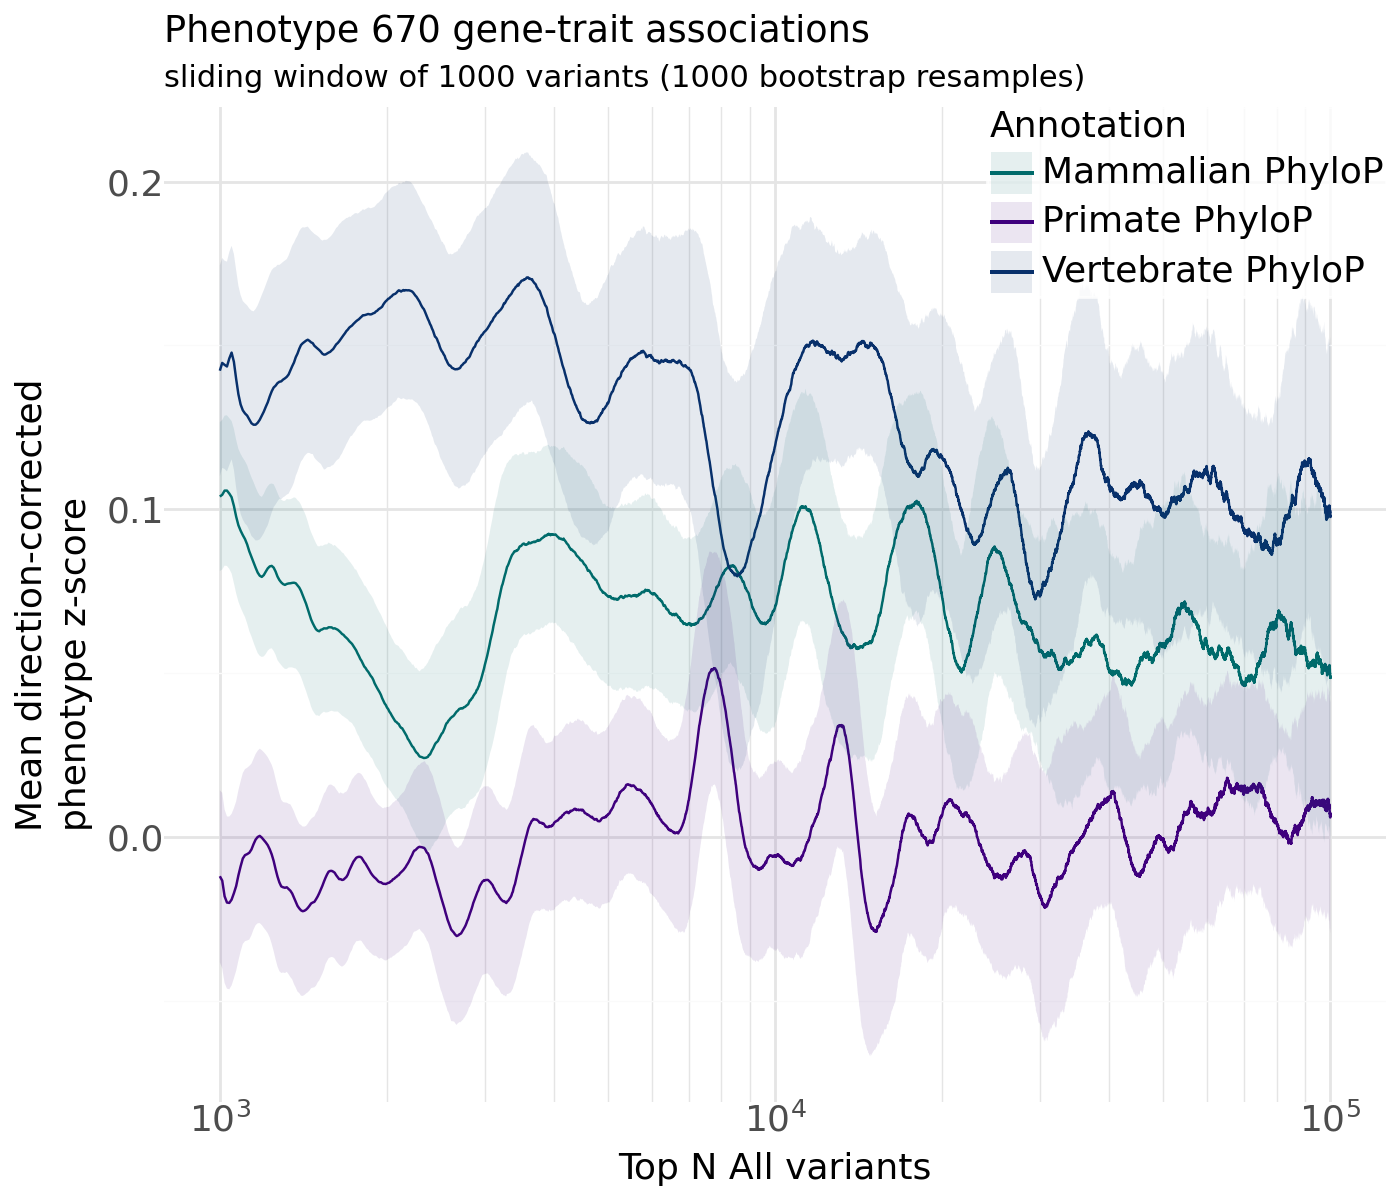

In [15]:
plot_df_small = (
    plt_df
    .filter(
        # (pl.col('bin_end') <= 10_000),
        # (~pl.col('annotation').is_in(['bayes_del', 'esm1b_llr']))
        (~pl.col('annotation').is_in(['zooverphylop', 'zoopriphylop']))
    )
)

# Generate breaks and labels for x-axis
max_rank = zscore_binned['bin_end'].max()
min_rank = zscore_binned['bin_end'].min()
start_exp = int(np.floor(np.log10(min_rank)))
end_exp = int(np.ceil(np.log10(max_rank)))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"$10^{{{int(b)}}}$" for b in breaks_linear]

# Generate logarithmic minor breaks (2 through 9 for each power of 10)
minor_breaks = []
for k in range(start_exp, end_exp):
    minor_breaks.extend([k + np.log10(m) for m in range(2, 10)])
minor_breaks = [b for b in minor_breaks if min_rank <= 10**b <= max_rank]

color_dict = dict(zip(plt_df['label'], plt_df['color']))

(
    ggplot(
        plot_df_small,
        aes(x='log_bin_end', y='mean_zscore')
    )
    # + loftee_point
    # + geom_hline(aes(yintercept=0), color='black', linetype='dotted')
    + geom_line(aes(color='label'))
    + geom_ribbon(aes(ymin='ci_lower', ymax='ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        title=f"Phenotype {gene_trait_df.shape[0]} gene-trait associations",
        subtitle=f"sliding window of {window_size} variants ({n_boot} bootstrap resamples)",
        y=f"Mean direction-corrected\nphenotype z-score",
        x=x_label,
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci,
        minor_breaks=minor_breaks # Add this line
    )
    + theme_minimal()
    + theme(
        figure_size=(7, 6),
        # title=element_text(size=13, lineheight=1.4),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        panel_grid_minor_x=element_line(color="#e5e5e5", size=0.5), # Explicitly style minor lines
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(1, 1),
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)

# Heatmap of significances

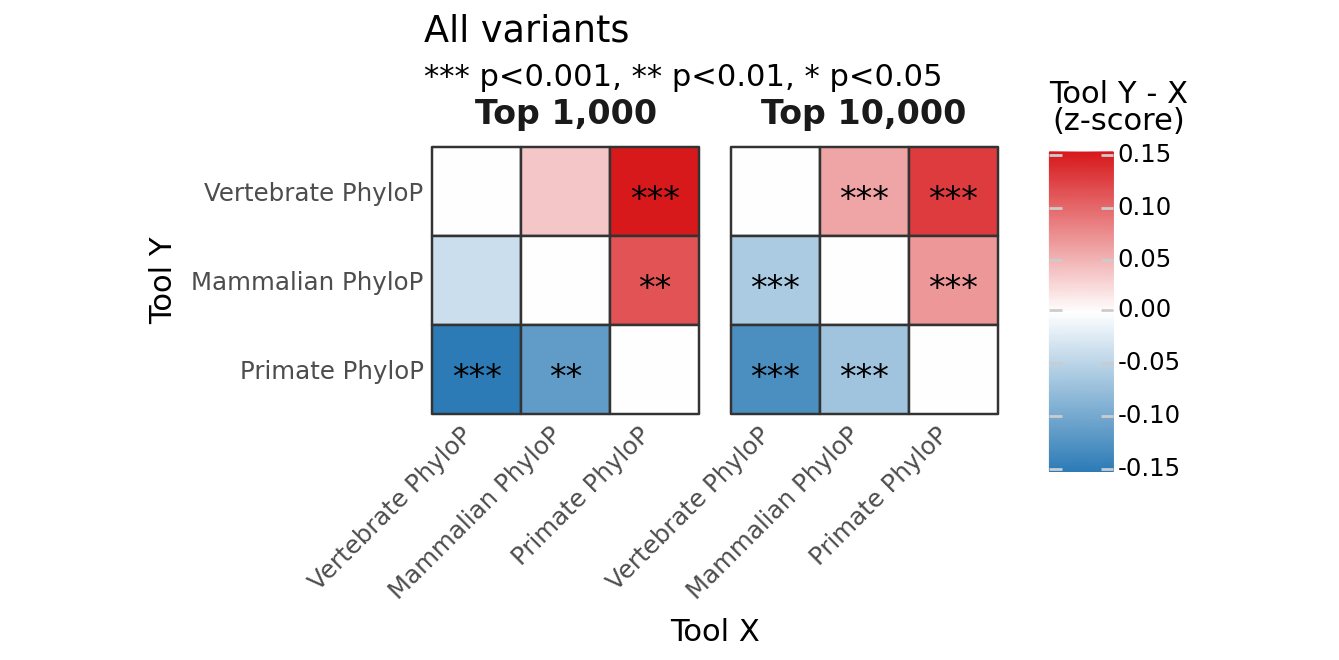

In [18]:
import pandas as pd
import itertools

# Build annotation name -> label mapping
anno_to_label = dict(zip(
    anno_config_df['annotation'].to_list(),
    anno_config_df['label'].to_list()
))

boot_discrete_plot = boot_discrete
boot_discrete_plot = {k: boot_discrete[k] for k in boot_discrete if k not in ['zooverphylop', 'zoopriphylop']}
# boot_discrete_plot = {k: boot_discrete[k] for k in ['promoterai_under', 'fz_all_min']}

# 1. Establish the global ranking of tools based on the middle window (e.g., Top 1,000)
# Assuming Top 1k is at index 0 in your target_k array
rank_idx = 0
tool_means = {ann: np.nanmean(boot_discrete_plot[ann][:, rank_idx]) for ann in boot_discrete_plot.keys()}

# Sort tools from highest mean to lowest mean
ordered_tools = sorted(tool_means.keys(), key=lambda x: tool_means[x], reverse=True)
ordered_labels = [anno_to_label.get(t, t) for t in ordered_tools]

heatmap_data = []

for i, k_val in enumerate(target_k):
    for ann_x, ann_y in itertools.product(ordered_tools, repeat=2):
        
        label_x = anno_to_label.get(ann_x, ann_x)
        label_y = anno_to_label.get(ann_y, ann_y)
        
        # Handle the diagonal (tool compared to itself)
        if ann_x == ann_y:
            heatmap_data.append({
                'Window': f"Top {k_val:,}",
                'Window_Int': k_val,
                'Tool_X': label_x,
                'Tool_Y': label_y,
                'mean_diff': 0.0,
                'sig': ''
            })
            continue
            
        boot_x = boot_discrete_plot[ann_x][:, i]
        boot_y = boot_discrete_plot[ann_y][:, i]
        
        diff = boot_y - boot_x
        mean_diff = np.nanmean(diff)
        
        # Two-tailed empirical p-value
        p_val = 2 * min(np.nanmean(diff <= 0), np.nanmean(diff >= 0))
        
        # Assign significance stars
        if p_val < 0.001: sig = '***'
        elif p_val < 0.01: sig = '**'
        elif p_val < 0.05: sig = '*'
        else: sig = ''
            
        heatmap_data.append({
            'Window': f"Top {k_val:,}",
            'Window_Int': k_val, 
            'Tool_X': label_x,
            'Tool_Y': label_y,
            'mean_diff': mean_diff,
            'sig': sig
        })

df_heat = pd.DataFrame(heatmap_data)
df_heat = df_heat.sort_values('Window_Int')

# Lock in the categorical order so best tools appear top/right
df_heat['Window'] = pd.Categorical(df_heat['Window'], categories=df_heat['Window'].unique(), ordered=True)
df_heat['Tool_X'] = pd.Categorical(df_heat['Tool_X'], categories=ordered_labels, ordered=True)
# Reverse Tool Y so the best tool is at the top of the y-axis
df_heat['Tool_Y'] = pd.Categorical(df_heat['Tool_Y'], categories=ordered_labels[::-1], ordered=True)

n_facets = len(target_k)
n_tools = len(ordered_tools)

(
    ggplot(df_heat, aes(x='Tool_X', y='Tool_Y', fill='mean_diff'))
    + geom_tile(color="#333333", size=0.5)
    + geom_text(aes(label='sig'), color="black", size=12, va='center', nudge_y=-0.1)
    + facet_wrap('~Window', ncol=n_facets)
    # scale_fill_gradient2 strictly centers the 'mid' color at zero
    + scale_fill_gradient2(low="#2C7BB6", mid="#FFFFFF", high="#D7191C", midpoint=0) 
    + labs(
        title=f"{vc['x_label']} variants",
        subtitle="*** p<0.001, ** p<0.01, * p<0.05",
        x="Tool X",
        y="Tool Y",
        fill="Tool Y - X\n(z-score)"
    )
    + theme_minimal()
    + theme(
        figure_size=(n_facets * (n_tools * 0.6 + 0.8) + 1.5, n_tools * 0.6 + 1.5),
        aspect_ratio=1,
        axis_text_x=element_text(rotation=45, hjust=1),
        strip_text=element_text(size=12, face='bold'),
        panel_grid=element_blank(),
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)